<a href="https://colab.research.google.com/github/SakshyamKarki/ML/blob/master/Regression_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Files**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
files.upload()

df = pd.read_csv("StudentPerformance.csv")

Saving StudentPerformance.csv to StudentPerformance.csv


# **Data Preprocessing**

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
df.isna().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
df.shape

(10000, 6)

In [ ]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
df.groupby(['Hours Studied'])['Performance Index'].describe()

,count,mean,std,min,25%,50%,75%,max
Hours Studied,,,,,,,,
1,1152.0,44.116319,18.122865,10.0,28.0,44.0,60.0,79.0
2,1085.0,46.428571,17.651237,11.0,32.0,46.0,61.0,82.0
3,1119.0,49.776586,17.505996,15.0,35.0,50.0,65.0,84.0
4,1085.0,52.719816,18.145548,18.0,37.0,53.0,69.0,87.0
5,1094.0,55.516453,17.603106,23.0,40.0,55.0,71.0,91.0
6,1133.0,58.486320,17.739154,23.0,44.0,59.0,74.0,93.0
7,1129.0,60.233835,17.847668,28.0,44.0,60.0,76.0,96.0
8,1088.0,64.211397,17.846771,26.0,49.0,64.0,80.0,99.0
9,1115.0,65.725561,17.919079,32.0,51.0,65.0,81.0,100.0


# **Data Visualization**

In [ ]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [ ]:
df['Extracurricular Activities'] = (df['Extracurricular Activities'] == 'Yes').astype(int)

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


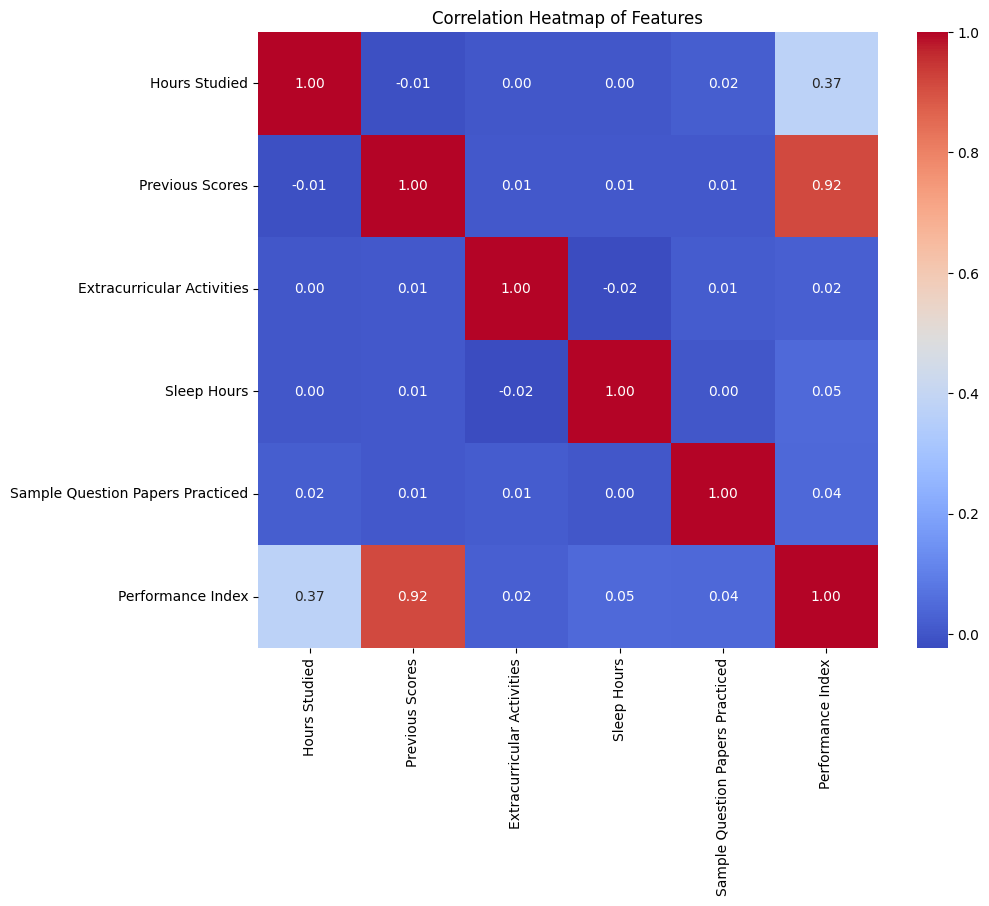

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Features")
plt.show()

# **Simple Linear Regression**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, r2_score

In [ ]:
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [ ]:
X, y

(      Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
 0                 7               99                           1            9   
 1                 4               82                           0            4   
 2                 8               51                           1            7   
 3                 5               52                           1            5   
 4                 7               75                           0            8   
 ...             ...              ...                         ...          ...   
 9995              1               49                           1            4   
 9996              7               64                           1            8   
 9997              6               83                           1            8   
 9998              9               97                           1            7   
 9999              7               74                           0            8   
 
       Sample 

In [ ]:
X_simple = df[["Previous Scores"]]
y_simple = y

X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.25, random_state=42)

simple_model =LinearRegression()
simple_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = simple_model.predict(X_test)

print("Simple Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Simple Linear Regression
MAE: 6.52858945184096
MSE: 58.670594387484655
RMSE: 7.659673255921865
R² Score: 0.8407592881001957


In [ ]:
print(f"Simple Regression Model: y(Performance Index) = {simple_model.coef_[0]:.2f} * x(Previous Score) + {simple_model.intercept_:.2f}")

Simple Regression Model: y(Performance Index) = 1.01 * x(Previous Score) + -15.17


In [ ]:
print(simple_model.predict([[80]]))
# X_test

[65.91870777]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# **Multiple Linear Regression**

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [ ]:
X = df[['Hours Studied', 'Previous Scores']]

y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
y_pred_multi = multi_model.predict(X_test)

In [ ]:
print("Multiple Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_multi))
print("MSE:", mean_squared_error(y_test, y_pred_multi))
print("RMSE:", root_mean_squared_error(y_test, y_pred_multi))
print("R² Score:", r2_score(y_test, y_pred_multi))

Multiple Linear Regression
MAE: 1.8101437492369952
MSE: 5.201346140631689
RMSE: 2.2806459919574738
R² Score: 0.9859445764337783


In [ ]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": multi_model.coef_
})

coeff_df

,Feature,Coefficient
0,Hours Studied,2.864492
1,Previous Scores,1.016152


In [ ]:
multi_model.predict([[4, 56]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([38.75713361])

# **Logistic Regression**

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [ ]:
df.groupby(['Sleep Hours'])['Extracurricular Activities'].mean()

,Extracurricular Activities
Sleep Hours,
4,0.507103
5,0.501245
6,0.511058
7,0.494033
8,0.482262
9,0.474106


In [ ]:
df['Pass'] = (df['Performance Index'] >= 40).astype(int)

df['Pass']

,Pass
0,1
1,1
2,1
3,0
4,1
...,...
9995,0
9996,1
9997,1
9998,1


In [ ]:
df['Hardworking'] = (df['Hours Studied'] > 4).astype(int)

df['Hardworking']

,Hardworking
0,1
1,0
2,1
3,1
4,1
...,...
9995,0
9996,1
9997,1
9998,1


In [ ]:
df.groupby('Hours Studied')['Pass'].mean()

,Pass
Hours Studied,
1,0.564236
2,0.620276
3,0.688114
4,0.713364
5,0.769653
6,0.820830
7,0.834367
8,0.910846
9,0.938117


In [ ]:
df.groupby('Performance Index')['Pass'].mean()

,Pass
Performance Index,
10.0,0.0
11.0,0.0
12.0,0.0
13.0,0.0
14.0,0.0
...,...
96.0,1.0
97.0,1.0
98.0,1.0


In [ ]:
df.groupby('Hours Studied')['Hardworking'].mean()

,Hardworking
Hours Studied,
1,0.0
2,0.0
3,0.0
4,0.0
5,1.0
6,1.0
7,1.0
8,1.0
9,1.0


In [ ]:
from sklearn.linear_model import LogisticRegression

X = df[["Hours Studied"]]
y = df["Hardworking"]

X, y

(      Hours Studied
 0                 7
 1                 4
 2                 8
 3                 5
 4                 7
 ...             ...
 9995              1
 9996              7
 9997              6
 9998              9
 9999              7
 
 [10000 rows x 1 columns],
 0       1
 1       0
 2       1
 3       1
 4       1
        ..
 9995    0
 9996    1
 9997    1
 9998    1
 9999    1
 Name: Hardworking, Length: 10000, dtype: int64)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)


In [ ]:
print("Logistic Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_log))
print("MSE:", mean_squared_error(y_test, y_pred_log))
print("RMSE:", root_mean_squared_error(y_test, y_pred_log))
print("R² Score:", r2_score(y_test, y_pred_log))


Logistic Regression
MAE: 0.0
MSE: 0.0
RMSE: 0.0
R² Score: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


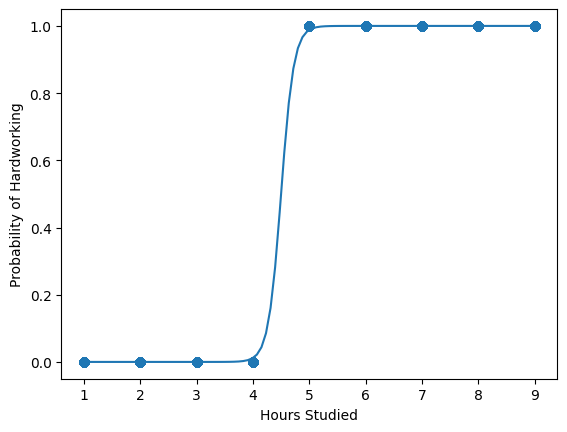

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_vals = np.linspace(1, 9, 100).reshape(-1,1)
y_vals = log_model.predict_proba(X_vals)[:,1]

plt.scatter(X, y)
plt.plot(X_vals, y_vals)
plt.xlabel("Hours Studied")
plt.ylabel("Probability of Hardworking")
plt.show()


# **Polynomial Regression**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Pass,Hardworking
0,7,99,1,9,1,91.0,1,1
1,4,82,0,4,2,65.0,1,0
2,8,51,1,7,2,45.0,1,1
3,5,52,1,5,2,36.0,0,1
4,7,75,0,8,5,66.0,1,1
...,...,...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0,0,0
9996,7,64,1,8,5,58.0,1,1
9997,6,83,1,8,5,74.0,1,1
9998,9,97,1,7,0,95.0,1,1


In [ ]:
X = df[['Hours Studied']]
y = df['Performance Index']

In [ ]:
def polynomial_regression(degree):
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Smooth curve for plotting
    X_range = np.linspace(0, 10, 100).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_pred = model.predict(X_range_poly)

    # Plot
    plt.figure()
    plt.scatter(X, y)
    plt.plot(X_range, y_pred)
    plt.xlabel("Hours Studied")
    plt.ylabel("Performance Index")
    plt.title(f"Polynomial Regression (Degree {degree})")
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


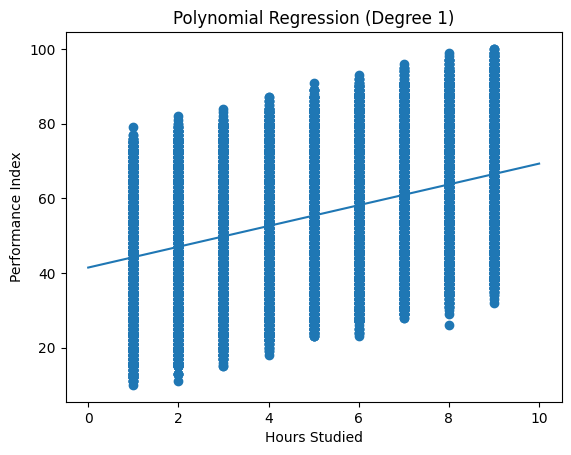

In [ ]:
polynomial_regression(degree=1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


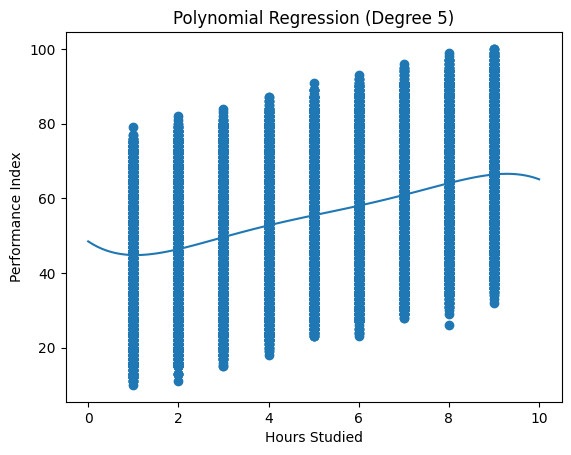

In [ ]:
polynomial_regression(degree=5)